# Pronóstico de Demanda Diaria por Tienda e Item

**Caso base del curso: Despliegue y Producción de Modelos de Machine Learning con Python**

Este notebook entrena un modelo de pronóstico de demanda y produce el artefacto que se va
a servir a través de una API durante el resto del curso.

### Qué construye

Un modelo que, dada la historia reciente de ventas de un par tienda-item, pronostica las
ventas de los próximos días.

### Decisión de diseño central

El modelo usa **solo variables calculables a partir de una ventana corta de historia
reciente** (rezagos de 1, 7, 14 y 28 días, más medias y desviaciones móviles).

Esto no es una simplificación arbitraria: es lo que hace posible servir el modelo por API.
Un cliente puede enviar los últimos 28 días en un JSON. Si el modelo dependiera de dos o
tres años de historia, el servicio tendría que cargar la base completa y el contrato de
entrada sería inviable.

### Dos funciones que van al servicio

Las celdas marcadas con **[SERVICIO]** contienen código que se copia sin cambios al
proyecto de FastAPI más adelante en el curso. No son código de exploración: son el módulo
de inferencia. Es el mismo código en el notebook y en producción, y eso es deliberado —
duplicar la lógica de features entre entrenamiento e inferencia es una de las causas más
comunes de fallas silenciosas en producción.

### Cómo recorrerlo

El notebook está pensado para ejecutarse de arriba hacia abajo, sin saltos. Antes de
empezar, colocá `train.csv` en la carpeta indicada en la variable `RUTA` de la sección 1.

## 1. Configuración

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 4)

RUTA = ""          # carpeta donde estan train.csv y test.csv
CORTE_VALIDACION = "2017-10-01"
MUESTRA = None     # None = usar todas las series. Ej: 10 = solo los primeros 10 items (mas rapido en clase)

print("pandas   ", pd.__version__)
print("numpy    ", np.__version__)
print("lightgbm ", lgb.__version__)
print("sklearn  ", sklearn.__version__)

pandas    3.0.5
numpy     2.5.2
lightgbm  4.7.0
sklearn   1.9.0


## 2. Carga y verificación de datos

Antes de modelar, tres verificaciones que en producción son obligatorias: rango de fechas,
completitud de la serie y ausencia de nulos. Un hueco en las fechas rompe los rezagos de
forma silenciosa: el modelo se entrena igual, sin errores visibles, pero con variables
mal calculadas.

In [3]:
train = pd.read_csv(os.path.join(RUTA, "train.csv"), parse_dates=["date"])

if MUESTRA:
    train = train[train.item <= MUESTRA]

print("Filas:", f"{len(train):,}")
print("Rango:", train.date.min().date(), "->", train.date.max().date())
print("Tiendas:", train.store.nunique(), "| Items:", train.item.nunique(),
      "| Series:", train.store.nunique() * train.item.nunique())
print("Nulos:", train.isna().sum().sum())

# Cada serie debe tener un registro por dia, sin huecos
conteo = train.groupby(["store", "item"]).date.agg(["count", "min", "max"])
dias_esperados = (train.date.max() - train.date.min()).days + 1
print("Dias esperados por serie:", dias_esperados)
print("Series completas:", (conteo["count"] == dias_esperados).all())

train.head()

Filas: 913,000
Rango: 2013-01-01 -> 2017-12-31
Tiendas: 10 | Items: 50 | Series: 500
Nulos: 0
Dias esperados por serie: 1826
Series completas: True


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
train.sales.describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
sales,913000.0,52.250287,28.801144,0.0,30.0,47.0,70.0,231.0


## 3. Exploración mínima

Cuatro gráficos, no veinte. El objetivo acá es identificar los patrones que el modelo
debe capturar, no producir un informe de análisis exploratorio completo.

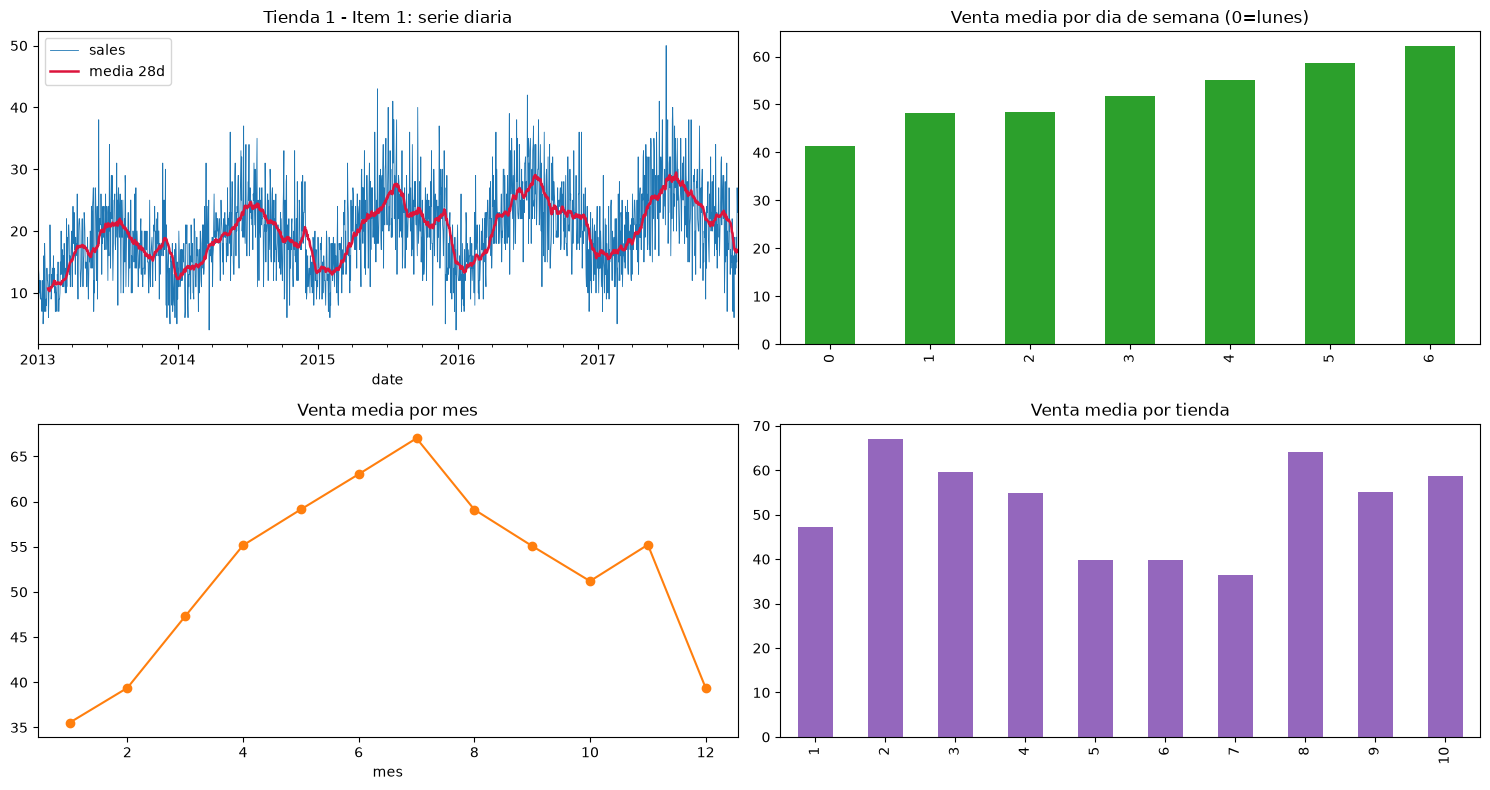

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

# 3.1 Una serie individual: el objeto que vamos a pronosticar
s = train[(train.store == 1) & (train.item == 1)].set_index("date").sales
s.plot(ax=ax[0, 0], lw=0.6, color="#1f77b4")
s.rolling(28).mean().plot(ax=ax[0, 0], color="crimson", lw=1.8, label="media 28d")
ax[0, 0].set_title("Tienda 1 - Item 1: serie diaria"); ax[0, 0].legend()

# 3.2 Estacionalidad semanal
train.groupby(train.date.dt.dayofweek).sales.mean().plot.bar(ax=ax[0, 1], color="#2ca02c")
ax[0, 1].set_title("Venta media por dia de semana (0=lunes)")
ax[0, 1].set_xlabel("")

# 3.3 Estacionalidad anual
train.groupby(train.date.dt.month).sales.mean().plot(ax=ax[1, 0], marker="o", color="#ff7f0e")
ax[1, 0].set_title("Venta media por mes"); ax[1, 0].set_xlabel("mes")

# 3.4 Heterogeneidad entre tiendas
train.groupby("store").sales.mean().plot.bar(ax=ax[1, 1], color="#9467bd")
ax[1, 1].set_title("Venta media por tienda"); ax[1, 1].set_xlabel("")

plt.tight_layout(); plt.show()

**Lectura:** hay tendencia creciente, estacionalidad semanal fuerte (fin de semana más
alto), estacionalidad anual con pico a mitad de año, y niveles muy distintos entre
tiendas. Los rezagos de 1 y 7 días capturan lo primero, las variables de calendario lo
segundo, y el identificador de tienda-item lo último.

## 4. Ingeniería de variables

Dos reglas que la hacen apta para producción:

1. **Todo rezago es estrictamente pasado.** Las medias móviles llevan `shift(1)` antes
   del `rolling`, de modo que nunca incluyen el día que se está prediciendo. Sin ese
   `shift(1)` el modelo se ve excelente en validación y falla en producción: es una fuga
   de información (*data leakage*).
2. **La ventana es acotada.** El rezago más largo es de 28 días, lo cual define el mínimo
   de historia que el cliente debe enviar.

In [6]:
LAGS = [1, 7, 14, 28]
VENTANAS = [7, 28]
MIN_HISTORIAL = max(LAGS + VENTANAS)   # 28 dias

COLUMNAS = (["store", "item", "dia_semana", "dia_mes", "mes", "semana_anio",
             "dia_anio", "es_fin_semana"]
            + [f"lag_{l}" for l in LAGS]
            + [f"media_{v}" for v in VENTANAS]
            + [f"std_{v}" for v in VENTANAS])


def crear_calendario(df):
    """Variables derivadas solo de la fecha. No requieren historia."""
    df = df.copy()
    df["dia_semana"]    = df.date.dt.dayofweek
    df["dia_mes"]       = df.date.dt.day
    df["mes"]           = df.date.dt.month
    df["semana_anio"]   = df.date.dt.isocalendar().week.astype(int)
    df["dia_anio"]      = df.date.dt.dayofyear
    df["es_fin_semana"] = (df.dia_semana >= 5).astype(int)
    return df


def crear_lags(df, grupo=["store", "item"]):
    """Rezagos y estadisticas moviles por serie. Siempre desplazados: nunca usan el dia actual."""
    df = df.sort_values(grupo + ["date"]).copy()
    g = df.groupby(grupo)["sales"]
    for lag in LAGS:
        df[f"lag_{lag}"] = g.shift(lag)
    for v in VENTANAS:
        df[f"media_{v}"] = g.transform(lambda s: s.shift(1).rolling(v).mean())
        df[f"std_{v}"]   = g.transform(lambda s: s.shift(1).rolling(v).std())
    return df


def crear_features(df, grupo=["store", "item"]):
    """Punto de entrada unico. Se usa igual en entrenamiento y en inferencia."""
    return crear_lags(crear_calendario(df), grupo)


print(f"{len(COLUMNAS)} variables | historia minima requerida: {MIN_HISTORIAL} dias")

16 variables | historia minima requerida: 28 dias


In [7]:
df = crear_features(train)

# Las primeras 28 filas de cada serie no tienen rezagos completos
antes = len(df)
df = df.dropna(subset=COLUMNAS)
print(f"Filas: {antes:,} -> {len(df):,}  (se descartan {antes - len(df):,} por rezagos incompletos)")

df[["date", "store", "item", "sales"] + COLUMNAS[8:]].head()

Filas: 913,000 -> 899,000  (se descartan 14,000 por rezagos incompletos)


,date,store,item,sales,lag_1,lag_7,lag_14,lag_28,media_7,media_28,std_7,std_28
28,2013-01-29,1,1,6,11.0,7.0,5.0,13.0,10.428571,10.714286,2.507133,3.077483
29,2013-01-30,1,1,9,6.0,9.0,7.0,11.0,10.285714,10.464286,2.751623,3.167920
30,2013-01-31,1,1,13,9.0,8.0,16.0,14.0,10.285714,10.392857,2.751623,3.177925
31,2013-02-01,1,1,11,13.0,14.0,7.0,13.0,11.000000,10.357143,2.708013,3.141294
32,2013-02-02,1,1,21,11.0,12.0,18.0,10.0,10.571429,10.285714,2.370453,3.101459


## 5. División temporal

Nunca aleatoria. La validación es el bloque final del histórico, que simula lo que el
modelo verá en producción: predecir fechas posteriores a todo lo que conoce. Mezclar
fechas al azar daría una métrica optimista que no se sostiene al desplegar.

In [8]:
corte = pd.Timestamp(CORTE_VALIDACION)
tr = df[df.date <  corte]
va = df[df.date >= corte]

print(f"Entrenamiento: {len(tr):,} filas  ({tr.date.min().date()} -> {tr.date.max().date()})")
print(f"Validacion   : {len(va):,} filas  ({va.date.min().date()} -> {va.date.max().date()})")

Entrenamiento: 853,000 filas  (2013-01-29 -> 2017-09-30)
Validacion   : 46,000 filas  (2017-10-01 -> 2017-12-31)


## 6. Métrica

SMAPE (error porcentual absoluto medio simétrico). Se usa porque es porcentual —
comparable entre items de volumen muy distinto — y porque, a diferencia del MAPE, no se
indefine cuando la venta real es cero.

In [9]:
def smape(y_real, y_pred):
    y_real, y_pred = np.asarray(y_real, float), np.asarray(y_pred, float)
    denom = np.abs(y_real) + np.abs(y_pred)
    mask = denom != 0
    return 200 * np.mean(np.abs(y_real[mask] - y_pred[mask]) / denom[mask])

## 7. Entrenamiento

LightGBM con detención temprana sobre el conjunto de validación. Un solo modelo para las
500 series: `store` e `item` entran como variables, de modo que el modelo aprende los
niveles de cada combinación en lugar de requerir 500 modelos separados. Un único artefacto
también significa un único despliegue y una única versión que mantener.

In [10]:
modelo = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.1,
    num_leaves=31,
    random_state=384,
    verbose=-1,
)

modelo.fit(
    tr[COLUMNAS], tr.sales,
    eval_set=[(va[COLUMNAS], va.sales)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

print("Iteraciones usadas:", modelo.best_iteration_)
print("SMAPE entrenamiento:", round(smape(tr.sales, modelo.predict(tr[COLUMNAS])), 3))
print("SMAPE validacion   :", round(smape(va.sales, modelo.predict(va[COLUMNAS])), 3))

Iteraciones usadas: 598
SMAPE entrenamiento: 12.646
SMAPE validacion   : 12.494


Un SMAPE de validación cercano a 12.5 es un resultado competitivo para este conjunto de
datos. La brecha pequeña entre entrenamiento y validación indica que no hay sobreajuste
severo.

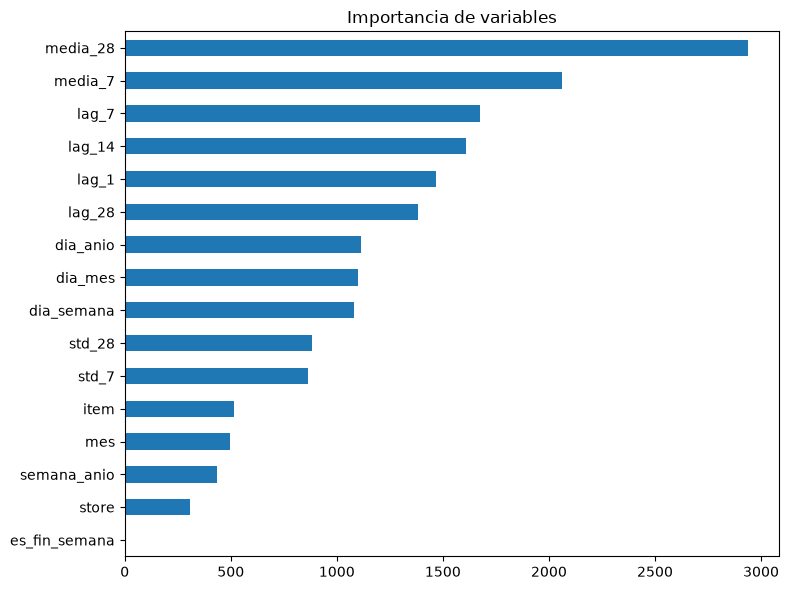

In [11]:
imp = (pd.Series(modelo.feature_importances_, index=COLUMNAS)
         .sort_values(ascending=False))
imp.plot.barh(figsize=(8, 6), color="#1f77b4").invert_yaxis()
plt.title("Importancia de variables"); plt.tight_layout(); plt.show()

## 8. Pronóstico recursivo

El modelo predice **un día**. Para pronosticar catorce, se predice el día siguiente, se
agrega esa predicción a la historia como si fuera un dato real, se recalculan los rezagos
y se repite. Eso se llama estrategia recursiva, y tiene una consecuencia importante: el
error se acumula con el horizonte. Cuanto más lejos se pronostica, más se apoya el modelo
en sus propias predicciones en lugar de en datos reales.

Notá que se llama a `crear_features`, la misma función del entrenamiento. Ese es el punto:
una sola definición de las variables para los dos mundos.

In [12]:
def pronosticar(bundle, historial, horizonte=14):
    """
    bundle    : dict con modelo, columnas y configuracion
    historial : DataFrame con columnas date, store, item, sales (al menos 28 filas, sin huecos)
    horizonte : cantidad de dias a pronosticar
    devuelve  : lista de dicts {fecha, prediccion}
    """
    modelo, columnas = bundle["modelo"], bundle["columnas"]
    minimo = bundle["min_historial"]

    h = historial.copy()
    h["date"] = pd.to_datetime(h["date"])
    h = h.sort_values("date").reset_index(drop=True)

    if len(h) < minimo:
        raise ValueError(f"Se requieren al menos {minimo} dias de historia, se recibieron {len(h)}")
    if h.date.diff().dropna().ne(pd.Timedelta(days=1)).any():
        raise ValueError("El historial tiene fechas faltantes o desordenadas")

    store, item = int(h.store.iloc[-1]), int(h.item.iloc[-1])
    resultado = []

    for _ in range(horizonte):
        siguiente = h.date.iloc[-1] + pd.Timedelta(days=1)
        h = pd.concat(
            [h, pd.DataFrame([{"date": siguiente, "store": store, "item": item, "sales": np.nan}])],
            ignore_index=True,
        )
        fila = crear_features(h).iloc[[-1]]
        pred = max(0.0, float(modelo.predict(fila[columnas])[0]))
        h.loc[h.index[-1], "sales"] = pred          # se realimenta como si fuera dato real
        resultado.append({"fecha": siguiente.date().isoformat(), "prediccion": round(pred, 2)})

    return resultado

## 9. Serialización del artefacto

No se guarda el modelo solo. Se guarda un **bundle**: modelo, orden exacto de las
columnas, configuración de rezagos y versiones de las librerías.

El orden de las columnas importa porque LightGBM recibe una matriz posicional: si la API
las arma en otro orden, el modelo predice sin error y con resultados absurdos. Las
versiones importan porque cargar un artefacto con una versión distinta de la que lo creó
puede fallar o, peor, funcionar con comportamiento cambiado.

In [13]:
bundle = {
    "modelo": modelo,
    "columnas": COLUMNAS,
    "lags": LAGS,
    "ventanas": VENTANAS,
    "min_historial": MIN_HISTORIAL,
    "horizonte_maximo": 28,
    "metrica": {"smape_validacion": float(round(smape(va.sales, modelo.predict(va[COLUMNAS])), 3))},
    "entrenado_hasta": str(df.date.max().date()),
    "versiones": {
        "pandas":   pd.__version__,
        "numpy":    np.__version__,
        "lightgbm": lgb.__version__,
        "sklearn":  sklearn.__version__,
    },
}

joblib.dump(bundle, "modelo_demanda.joblib")
print("Artefacto guardado:", round(os.path.getsize("modelo_demanda.joblib") / 1024 / 1024, 2), "MB")

Artefacto guardado: 1.69 MB


## 10. Verificación del artefacto

Se recarga el bundle desde disco y se pronostica, simulando lo que hará la API. Si esto
falla, el artefacto no sirve, sin importar qué tan bueno sea el SMAPE.

Conviene repetir este paso en un intérprete limpio (una terminal nueva, fuera del
notebook) para comprobar que el artefacto no depende de nada que solo exista en la memoria
de esta sesión.

In [15]:
bundle_cargado = joblib.load("modelo_demanda.joblib")

# Lo que enviaria un cliente: los ultimos 28 dias de una serie
historial = (train[(train.store == 1) & (train.item == 1)]
             .tail(MIN_HISTORIAL)[["date", "store", "item", "sales"]]
             .reset_index(drop=True))

pronostico = pronosticar(bundle_cargado, historial, horizonte=14)

print(json.dumps(pronostico, indent=2, ensure_ascii=False))

[
  {
    "fecha": "2018-01-01",
    "prediccion": 12.65
  },
  {
    "fecha": "2018-01-02",
    "prediccion": 15.56
  },
  {
    "fecha": "2018-01-03",
    "prediccion": 15.25
  },
  {
    "fecha": "2018-01-04",
    "prediccion": 16.36
  },
  {
    "fecha": "2018-01-05",
    "prediccion": 17.12
  },
  {
    "fecha": "2018-01-06",
    "prediccion": 18.48
  },
  {
    "fecha": "2018-01-07",
    "prediccion": 19.19
  },
  {
    "fecha": "2018-01-08",
    "prediccion": 13.04
  },
  {
    "fecha": "2018-01-09",
    "prediccion": 14.78
  },
  {
    "fecha": "2018-01-10",
    "prediccion": 14.94
  },
  {
    "fecha": "2018-01-11",
    "prediccion": 15.95
  },
  {
    "fecha": "2018-01-12",
    "prediccion": 16.52
  },
  {
    "fecha": "2018-01-13",
    "prediccion": 17.96
  },
  {
    "fecha": "2018-01-14",
    "prediccion": 19.63
  }
]


### El JSON que la API va a devolver

Esta salida es exactamente el contrato de respuesta que se va a implementar con Pydantic
más adelante. Vale la pena verlo antes de escribir la API: el objetivo de lo que sigue es
publicar esta misma lista a través de HTTP.

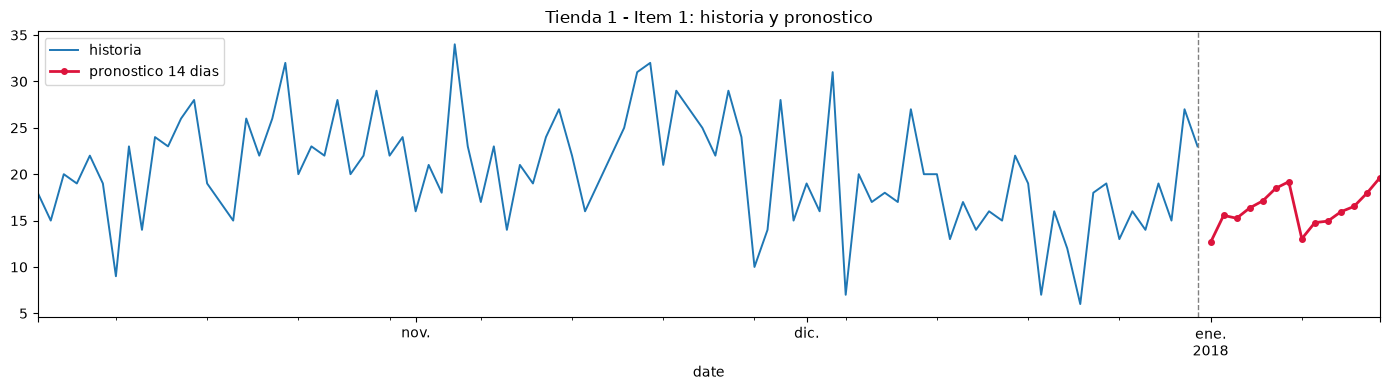

In [16]:
hist_plot = (train[(train.store == 1) & (train.item == 1)]
             .tail(90).set_index("date").sales)
pred_plot = pd.Series([p["prediccion"] for p in pronostico],
                      index=pd.to_datetime([p["fecha"] for p in pronostico]))

ax = hist_plot.plot(label="historia", color="#1f77b4", lw=1.4)
pred_plot.plot(ax=ax, label="pronostico 14 dias", color="crimson", lw=2, marker="o", ms=4)
ax.axvline(hist_plot.index[-1], color="gray", ls="--", lw=1)
ax.set_title("Tienda 1 - Item 1: historia y pronostico"); ax.legend()
plt.tight_layout(); plt.show()

## Cierre y puente al despliegue

Al terminar este notebook existen tres artefactos:

| Archivo | Rol |
|---|---|
| `modelo_demanda.joblib` | El bundle que la API va a cargar al arrancar |
| `requirements-modelo.txt` | Las versiones que la imagen debe instalar |
| Las funciones `crear_features` y `pronosticar` | El módulo de inferencia del servicio |

**Contrato de entrada** que se construirá sobre esta base:

```json
{
  "store": 1,
  "item": 1,
  "historial": [
    {"fecha": "2017-12-04", "unidades": 19},
    "... al menos 28 registros, consecutivos y sin huecos ..."
  ],
  "horizonte": 14
}
```

Reglas de validación que se derivan directamente de lo construido acá:

- Mínimo 28 registros de historia (lo exige `MIN_HISTORIAL`)
- Fechas consecutivas, ordenadas y sin huecos
- Horizonte entre 1 y 28
- Unidades no negativas
- `store` entre 1 y 10, `item` entre 1 y 50

### Lo que este notebook no hace, a propósito

- No usa `test.csv`. Ese archivo es el conjunto de evaluación de la competencia original y
  no tiene la columna `sales`, por lo que no sirve para medir. La validación se hace con el
  último trimestre del histórico.
- No busca hiperparámetros. Con 16 variables y detención temprana, la ganancia de una
  búsqueda es de décimas de SMAPE frente a un costo de cómputo bastante mayor.
- No usa SHAP ni interpretabilidad avanzada. Es un tema valioso, pero pertenece a un curso
  de modelado, no a uno de despliegue.

### Para practicar por tu cuenta

- Cambiá `CORTE_VALIDACION` y observá cómo se mueve el SMAPE.
- Agregá o quitá rezagos en `LAGS` y mirá el efecto en `MIN_HISTORIAL`: cada rezago nuevo
  cambia el contrato de entrada de la API.
- Pronosticá otra combinación de tienda-item y compará la forma de la curva.